In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tabular-playground-series-dec-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-dec-2021/train.csv
/kaggle/input/tabular-playground-series-dec-2021/test.csv


# Import Library

# T.P.S Submission File

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import mode



from lightgbm import LGBMClassifier



from matplotlib import ticker
import time
import warnings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('float_format', '{:f}'.format)
warnings.filterwarnings('ignore')

# Data Loading and Preperation

In [3]:
train = pd.read_csv("../input/tabular-playground-series-dec-2021/train.csv")
test = pd.read_csv("../input/tabular-playground-series-dec-2021/test.csv")
submission = pd.read_csv("../input/tabular-playground-series-dec-2021/sample_submission.csv")


train.drop(["Id"] , axis = 1 , inplace = True)
test.drop(["Id"] , axis = 1 , inplace = True)
TARGET = 'Cover_Type'  
FEATURES = [col for col in train.columns if col not in ['id', TARGET]]
RANDOM_STATE = 12 

<a id="3.1"></a>
# Exploring Train Data

## Quick view of Train Data

In [4]:
train.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,3189,40,8,30,13,3270,206,234,193,4873,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
1,3026,182,5,280,29,3270,233,240,106,5423,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2
2,3106,13,7,351,37,2914,208,234,137,5269,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
3,3022,276,13,192,16,3034,207,238,156,2866,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2
4,2906,186,13,266,22,2916,231,231,154,2642,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2


In [5]:
print(f'Number of rows in train data: {train.shape[0]}')
print(f'Number of columns in train data: {train.shape[1]}')
print(f'No of missing values in train data: {sum(train.isna().sum())}')

Number of rows in train data: 4000000
Number of columns in train data: 55
No of missing values in train data: 0


## Basic statistics of training data

In [6]:
train.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000,4000000.000000
mean,2980.191660,151.585671,15.097537,271.315436,51.662621,1766.641630,211.837542,221.061441,140.810874,1581.406810,0.261193,0.041661,0.653573,0.021819,0.016841,0.030896,0.004275,0.037913,0.015715,0.007973,0.000000,0.002900,0.010893,0.054541,0.027985,0.018290,0.031295,0.014977,0.000000,0.015888,0.020672,0.013436,0.013811,0.017368,0.011539,0.031346,0.049171,0.025022,0.003258,0.013527,0.011766,0.010708,0.022274,0.028867,0.027493,0.037462,0.037821,0.011995,0.016053,0.010713,0.012207,0.040752,0.039239,0.031619,1.771335
std,289.048167,109.961122,8.546731,226.549680,68.215966,1315.609890,30.759956,22.231335,43.698639,1127.616169,0.439285,0.199813,0.475831,0.146092,0.128677,0.173036,0.065247,0.190985,0.124372,0.088934,0.000000,0.053771,0.103800,0.227082,0.164931,0.133998,0.174115,0.121459,0.000000,0.125044,0.142283,0.115133,0.116707,0.130638,0.106798,0.174251,0.216224,0.156191,0.056988,0.115516,0.107830,0.102923,0.147572,0.167433,0.163516,0.189891,0.190763,0.108863,0.125681,0.102947,0.109811,0.197714,0.194164,0.174982,0.893806
min,1773.000000,-33.000000,-3.000000,-92.000000,-317.000000,-287.000000,-4.000000,49.000000,-53.000000,-277.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2760.000000,60.000000,9.000000,110.000000,4.000000,822.000000,198.000000,210.000000,115.000000,781.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2966.000000,123.000000,14.000000,213.000000,31.000000,1436.000000,218.000000,224.000000,142.000000,1361.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0

# Exploring Test Data

## Quick view of Test Data

In [7]:
test.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40
0,2763,78,20,377,88,3104,218,213,195,1931,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2826,153,11,264,39,295,219,238,148,2557,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2948,57,19,56,44,852,202,217,163,1803,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,2926,119,6,158,134,2136,234,240,142,857,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2690,10,4,38,108,3589,213,221,229,431,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
print(f'Number of rows in test data: {test.shape[0]}')
print(f'Number of columns in test data: {test.shape[1]}')
print(f'No of missing values in test data: {sum(test.isna().sum())}')

Number of rows in test data: 1000000
Number of columns in test data: 54
No of missing values in test data: 0


<a id="3.3"></a>
# Submission File

In [9]:
submission.head()

,Id,Cover_Type
0,4000000,2
1,4000001,2
2,4000002,2
3,4000003,2
4,4000004,2


<a id="4"></a>
# EDA

## Overview of Data

In [10]:
train.iloc[:, :-1].describe().T.sort_values(by='std' , ascending = False)\
                     .style.background_gradient(cmap='turbo')\
                     .bar(subset=["max"], color='#3296B1')\
                     .bar(subset=["mean"], color='#1B71B1')\

,count,mean,std,min,25%,50%,75%,max
Horizontal_Distance_To_Roadways,4000000.000000,1766.641630,1315.609890,-287.000000,822.000000,1436.000000,2365.000000,7666.000000
Horizontal_Distance_To_Fire_Points,4000000.000000,1581.406810,1127.616169,-277.000000,781.000000,1361.000000,2084.000000,8075.000000
Elevation,4000000.000000,2980.191660,289.048167,1773.000000,2760.000000,2966.000000,3217.000000,4383.000000
Horizontal_Distance_To_Hydrology,4000000.000000,271.315436,226.549680,-92.000000,110.000000,213.000000,361.000000,1602.000000
Aspect,4000000.000000,151.585671,109.961122,-33.000000,60.000000,123.000000,247.000000,407.000000
Vertical_Distance_To_Hydrology,4000000.000000,51.662621,68.215966,-317.000000,4.000000,31.000000,78.000000,647.000000
Hillshade_3pm,4000000.000000,140.810874,43.698639,-53.000000,115.000000,142.000000,169.000000,272.000000
Hillshade_9am,4000000.000000,211.837542,30.759956,-4.000000,198.000000,218.000000,233.000000,301.000000
Hillshade_Noon,4000000.000000,221.061441,22.231335,49.000000,210.000000,224.000000,237.000000,279.000000
Slope,4000000.000000,15.097537,8.546731,-3.000000,9.000000,14.000000,20.000000,64.000000


## Continuos and Categorical Data Distribution

Total number of features: 54
Number of categorical features: 44
Number of continuos features: 10


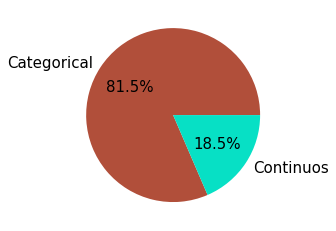

In [11]:
df = pd.concat([train[FEATURES], test[FEATURES]], axis=0)

cat_features = [col for col in FEATURES if df[col].nunique() < 9]
cont_features = [col for col in FEATURES if df[col].nunique() >= 9]

del df
print(f'Total number of features: {len(FEATURES)}')
print(f'Number of categorical features: {len(cat_features)}')
print(f'Number of continuos features: {len(cont_features)}')

plt.pie([len(cat_features), len(cont_features)],
       labels=['Categorical', 'Continuos'],
       colors=['#B14F3A', '#07E0C5'],
       textprops={'fontsize' : 15},
       autopct='%1.1f%%')

plt.show()

## Feature Distribution of Continous Features

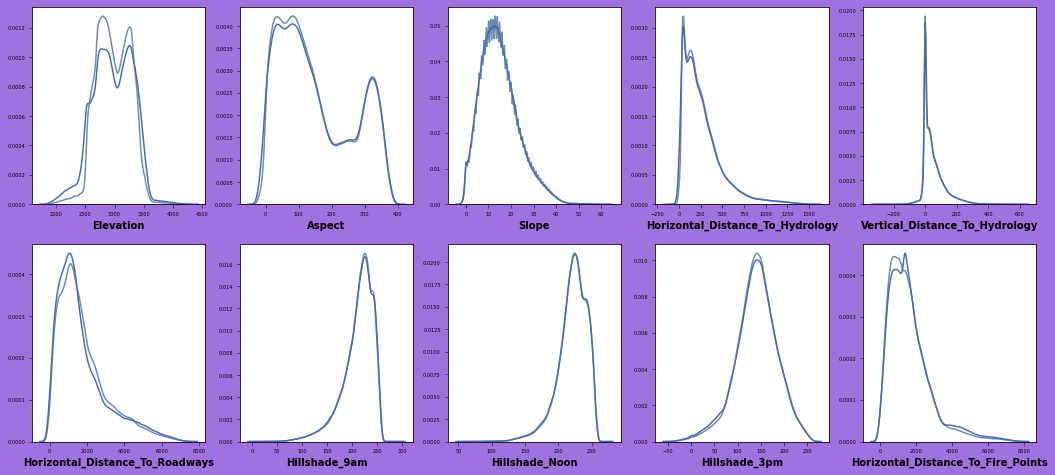

In [12]:
ncols = 5
nrows = int(len(cont_features) / ncols + (len(FEATURES) % ncols > 0))-1

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8), facecolor='#A171E0')

for r in range(nrows) :
    for c in range(ncols) :
        col = cont_features[r*ncols+c]
        sns.kdeplot(x=train[col], ax=axes[r, c], color='#6F8CB1', label='Train data')
        sns.kdeplot(x=test[col], ax=axes[r, c], color='#4A6BB1', label='Test data')
        axes[r, c].set_ylabel('')
        axes[r, c].set_xlabel(col, fontsize=10, fontweight='bold')
        axes[r, c].tick_params(labelsize=5, width=0.5)
        axes[r, c].xaxis.offsetText.set_fontsize(4)
        axes[r, c].yaxis.offsetText.set_fontsize(4)
        
plt.show()

## Feature Distribution of Categorical Features

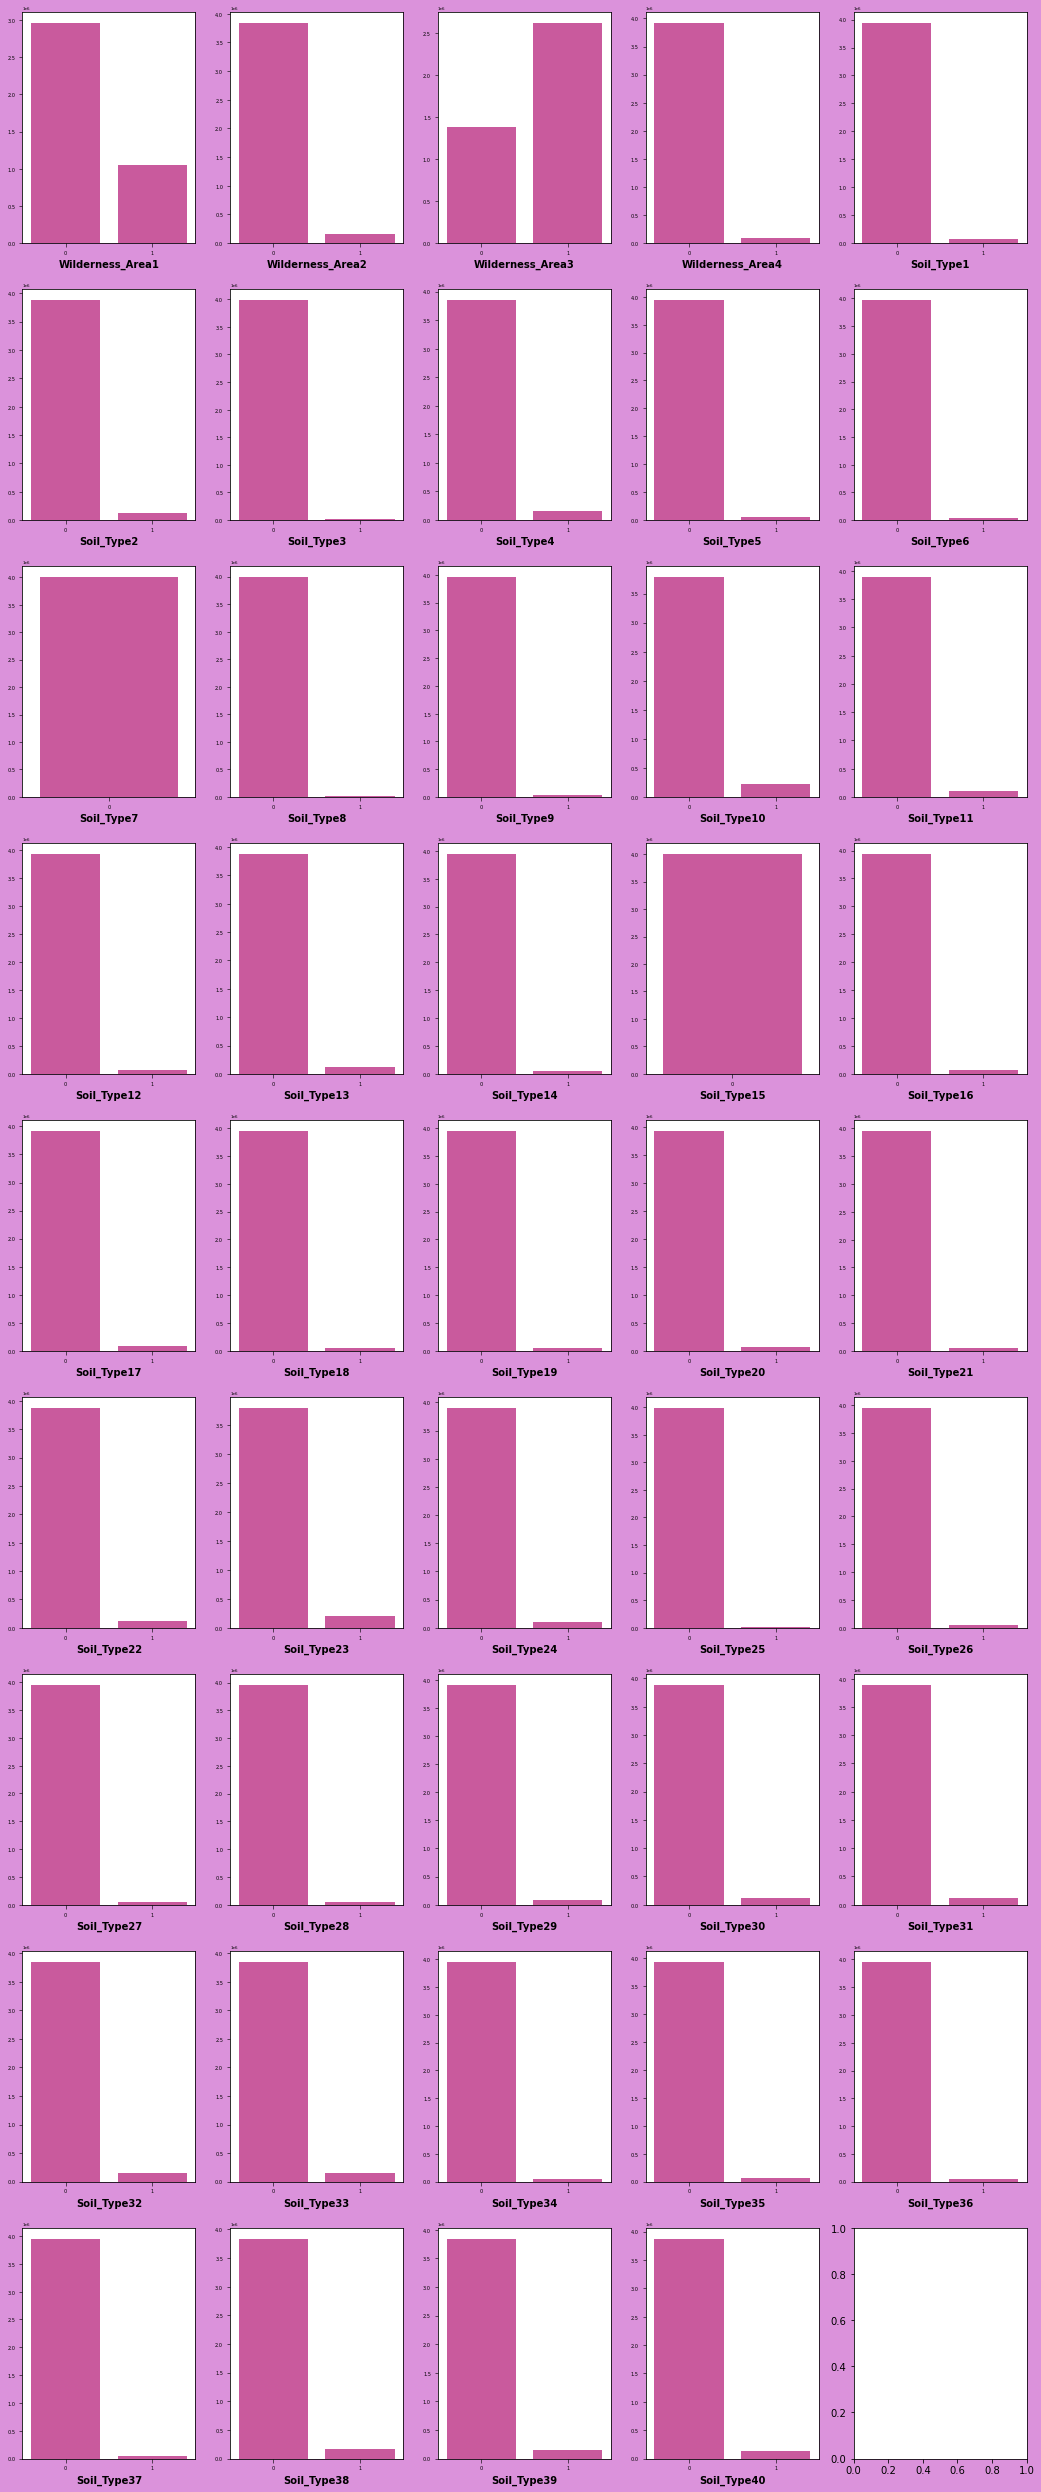

In [13]:
if len(cat_features) == 0 :
    print("No Categorical features")
else:
    ncols = 5
    nrows = int(len(cat_features) / ncols + (len(FEATURES) % ncols > 0))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 45), facecolor='#DB92DB')
    
    for r in range(nrows):
        for c in range(ncols):
            if r*ncols+c >= len(cat_features):
                break
            col = cat_features[r*ncols+c]
            sns.countplot(x=train[col], ax=axes[r, c], color='#97A0DB', label='Train Data')
            sns.countplot(x=train[col], ax=axes[r, c], color='#DB48A1', label='Test Data')
            axes[r, c].set_ylabel('')
            axes[r, c].set_xlabel(col, fontsize=10, fontweight='bold')
            axes[r, c].tick_params(labelsize=5, width=0.6)
            axes[r, c].xaxis.offsetText.set_fontsize(4)
            axes[r, c].yaxis.offsetText.set_fontsize(4)
            
plt.show()

## Target Distribution

In [14]:
target_df = pd.DataFrame(train[TARGET].value_counts()).reset_index()
target_df.columns = [TARGET, 'count']
fig = px.bar(data_frame = target_df,
            x = 'Cover_Type',
            y = 'count',
            color = "count",
            color_continuous_scale="Emrld")

fig.show()
target_df.sort_values(by =TARGET , ignore_index = True)

,Cover_Type,count
0,1,1468136
1,2,2262087
2,3,195712
3,4,377
4,5,1
5,6,11426
6,7,62261


### Removing Unwanted Rows and columns

In [15]:
train = train.drop(index = int(np.where(train["Cover_Type"] == 5 )[0]))
train = train.drop(labels = ["Soil_Type7" , "Soil_Type15"] ,axis = 1)
FEATURES.remove('Soil_Type7')
FEATURES.remove('Soil_Type15')

# Feature Engineering

In [16]:
train["mean"] = train[FEATURES].mean(axis=1)
train["std"] = train[FEATURES].std(axis=1)
train["min"] = train[FEATURES].min(axis=1)
train["max"] = train[FEATURES].max(axis=1)

test["mean"] = test[FEATURES].mean(axis=1)
test["std"] = test[FEATURES].std(axis=1)
test["min"] = test[FEATURES].min(axis=1)
test["max"] = test[FEATURES].max(axis=1)

FEATURES.extend(['mean', 'std', 'min', 'max'])

# Modeling

In [17]:
scaler = StandardScaler()
for col in FEATURES:
    train[col] = scaler.fit_transform(train[col].to_numpy().reshape(-1,1))
    test[col] = scaler.transform(test[col].to_numpy().reshape(-1,1))
    
X = train[FEATURES].to_numpy().astype(np.float32)
y = train[TARGET].to_numpy().astype(np.float32)
X_test = test[FEATURES].to_numpy().astype(np.float32)

# LGBM Classifier

In [18]:
lgb_params = {
    'objective' : 'multiclass',
    'metric' : 'multi_logloss',
    'device' : 'gpu',
}


lgb_predictions = []
lgb_scores = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for fold, (train_idx, valid_idx) in enumerate(kf.split(X = X, y = y)):

    print(10*"=", f"Fold={fold+1}", 10*"=")
    start_time = time.time()
    x_train = X[train_idx, :]
    x_valid = X[valid_idx, :]
    y_train = y[train_idx]
    y_valid = y[valid_idx]
    
    model = LGBMClassifier(**lgb_params)
    model.fit(x_train, y_train,
          early_stopping_rounds=200,
          eval_set=[(x_valid, y_valid)],
          verbose=0)
    
    preds_valid = model.predict(x_valid)
    acc = accuracy_score(y_valid,  preds_valid)
    lgb_scores.append(acc)
    run_time = time.time() - start_time
    print(f"Fold={fold+1}, acc: {acc:.8f}, Run Time: {run_time:.2f}")
    test_preds = model.predict(X_test)
    lgb_predictions.append(test_preds)
    
print("Mean Accuracy :", np.mean(lgb_scores))

========== Fold=1 ==========
Fold=1, acc: 0.94587375, Run Time: 149.55
========== Fold=2 ==========
Fold=2, acc: 0.95172000, Run Time: 150.94
========== Fold=3 ==========
Fold=3, acc: 0.94838625, Run Time: 145.89
========== Fold=4 ==========
Fold=4, acc: 0.94935625, Run Time: 156.39
========== Fold=5 ==========
Fold=5, acc: 0.94886244, Run Time: 146.27
Mean Accuracy : 0.948839737215609


# Submission 

### LGBM Classifier Submission

In [19]:
lgb_submission = submission.copy()
lgb_submission['Cover_Type'] = np.squeeze(mode(np.column_stack(lgb_predictions),axis = 1)[0]).astype('int')
lgb_submission.to_csv("lgb-subs.csv",index=None)
lgb_submission.head()

,Id,Cover_Type
0,4000000,2
1,4000001,2
2,4000002,2
3,4000003,2
4,4000004,2
